In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# IMPORT DATASETS


chamau_lag = pd.read_csv("../datasets/Chamau_2014-2024_clean_newlag.csv")
chamau_daily = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")

chamau_A = chamau_lag[chamau_lag["Parcel"] == "A"].copy()
chamau_B = chamau_lag[chamau_lag["Parcel"] == "B"].copy()

chamau_daily_A = chamau_daily[chamau_daily["Parcel"] == "A"]
chamau_daily_B = chamau_daily[chamau_daily["Parcel"] == "B"]

aeschi_lag = pd.read_csv("../datasets/Aeschi_2019-20_clean_newlag.csv")
aeschi_daily = pd.read_csv("../datasets/Aeschi_Daily_2019-20_newlag.csv")

oensingen_lag_1 = pd.read_csv("../datasets/Oensingen_2018-19_clean_newlag.csv")
oensingen_daily_1 = pd.read_csv("../datasets/Oensingen_Daily_2018-19_clean_newlag.csv")

oensingen_lag_2 = pd.read_csv("../datasets/Oensingen_2021-23_clean_newlag.csv")
oensingen_daily_2 = pd.read_csv("../datasets/Oensingen_Daily_2021-23_clean_newlag.csv")

tanikon_lag = pd.read_csv("../datasets/Tanikon_2023-25_clean_newlag.csv")
tanikon_daily = pd.read_csv("../datasets/Tanikon_Daily_2023-25_clean_newlag.csv")

tanikon_A = tanikon_lag[tanikon_lag["Parcel"] == "A"].copy()
tanikon_B = tanikon_lag[tanikon_lag["Parcel"] == "B"].copy()

tanikon_daily_A = tanikon_daily[tanikon_daily["Parcel"] == "A"]
tanikon_daily_B = tanikon_daily[tanikon_daily["Parcel"] == "B"]

forel_lag = pd.read_csv("../datasets/Forel_2024-25_clean_newlag.csv")
forel_daily = pd.read_csv("../datasets/Forel_Daily_2024-25_clean_newlag.csv")



In [3]:
hourly_datasets = {
    "Chamau": chamau_lag,
    "Chamau A": chamau_A,
    "Chamau B": chamau_B,
    "Aeschi": aeschi_lag,
    "Oensingen 1": oensingen_lag_1,
    "Oensingen 2": oensingen_lag_2,
    "Tanikon": tanikon_lag,
    "Tanikon A": tanikon_A,
    "Tanikon B": tanikon_B,
    "Forel": forel_lag
}   

daily_datasets = {
    "Chamau": chamau_daily,
    "Chamau A": chamau_daily_A,
    "Chamau B": chamau_daily_B,
    "Aeschi": aeschi_daily,
    "Oensingen 1": oensingen_daily_1,
    "Oensingen 2": oensingen_daily_2,
    "Tanikon": tanikon_daily,
    "Tanikon A": tanikon_daily_A,
    "Tanikon B": tanikon_daily_B,
    "Forel": forel_daily
}

In [49]:
# for name, df in daily_datasets.items():
#     print(f"\n{name} — {len(df.columns)} columns:")
#     print(df.columns.tolist())


In [4]:
target = "N2O_Flux_ln"


predictor_sets = {

    "base" : [

    "year",
    "month",

    # ============================================================
    # 2. CORE BIOGEOCHEMICAL FLUXES & METEOROLOGY
    # ============================================================
    "NEE",
    "GPP",
    "RECO",
    "SolarRadiation",
    "AirTemp",
    "VPD",
    "SoilWater_5cm",
    "SoilWater_15cm",
    "SoilWater_30cm",
    "SoilTemp_4cm",     # Chamau
    "SoilTemp_5cm",
    "SoilTemp_15cm",
    "SoilTemp_30cm",
    "Precipitation",
    "Fertilizer_N_kg_ha",

    # ============================================================
    # 4. DAYS-SINCE MANAGEMENT EVENTS (CALENDAR DAY)
    # ============================================================
    "DaysSince_Mowing",
    "DaysSince_FertilizerOrganic",
    "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation",
    "DaysSince_Sowing",
    "DaysSince_Grazing",   # Chamau only

    ],

    "augmented_lag" : [

    "year",
    "month",

    # ============================================================
    # 2. CORE BIOGEOCHEMICAL FLUXES & METEOROLOGY
    # ============================================================
    "NEE",
    "GPP",
    "RECO",
    "SolarRadiation",
    "AirTemp",
    "VPD",
    "SoilWater_5cm",
    "SoilWater_15cm",
    "SoilWater_30cm",
    "SoilTemp_4cm",     # Chamau
    "SoilTemp_5cm",
    "SoilTemp_15cm",
    "SoilTemp_30cm",
    "Precipitation",
    "Fertilizer_N_kg_ha",

    # ============================================================
    # 4. DAYS-SINCE MANAGEMENT EVENTS (CALENDAR DAY)
    # ============================================================
    "DaysSince_Mowing",
    "DaysSince_FertilizerOrganic",
    "DaysSince_FertilizerMineral",
    "DaysSince_SoilCultivation",
    "DaysSince_Sowing",
    "DaysSince_Grazing",   # Chamau only

    # ============================================================
    # 5. DAILY LAG FEATURES (1,3,5,7 days)
    # ============================================================

    # --- NEE ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "NEE_lag1d", "NEE_lag3d", "NEE_lag5d", "NEE_lag7d",

    # --- GPP ---
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "GPP_lag1d", "GPP_lag3d", "GPP_lag5d", "GPP_lag7d",

    # --- RECO ---
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "RECO_lag1d", "RECO_lag3d", "RECO_lag5d", "RECO_lag7d",

    # --- Solar Radiation ---
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily",
    "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "SolarRadiation_lag1d", "SolarRadiation_lag3d",
    "SolarRadiation_lag5d", "SolarRadiation_lag7d",

    # --- Air Temperature ---
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily",
    "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "AirTemp_lag1d", "AirTemp_lag3d",
    "AirTemp_lag5d", "AirTemp_lag7d",

    # --- VPD ---
    "VPD_lag1d_daily", "VPD_lag3d_daily",
    "VPD_lag5d_daily", "VPD_lag7d_daily",
    "VPD_lag1d", "VPD_lag3d",
    "VPD_lag5d", "VPD_lag7d",

    # --- SoilWater 5cm ---
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily",
    "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_5cm_lag1d", "SoilWater_5cm_lag3d",
    "SoilWater_5cm_lag5d", "SoilWater_5cm_lag7d",

    # --- SoilWater 15cm ---
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily",
    "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilWater_15cm_lag1d", "SoilWater_15cm_lag3d",
    "SoilWater_15cm_lag5d", "SoilWater_15cm_lag7d",

    # --- SoilWater 30cm ---
    "SoilWater_30cm_lag1d", "SoilWater_30cm_lag3d",
    "SoilWater_30cm_lag5d", "SoilWater_30cm_lag7d",

    # --- SoilTemp 4cm (Chamau) ---
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily",
    "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",

    # --- SoilTemp 5cm ---
    "SoilTemp_5cm_lag1d", "SoilTemp_5cm_lag3d",
    "SoilTemp_5cm_lag5d", "SoilTemp_5cm_lag7d",

    # --- SoilTemp 15cm ---
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily",
    "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "SoilTemp_15cm_lag1d", "SoilTemp_15cm_lag3d",
    "SoilTemp_15cm_lag5d", "SoilTemp_15cm_lag7d",

    # --- SoilTemp 30cm ---
    "SoilTemp_30cm_lag1d", "SoilTemp_30cm_lag3d",
    "SoilTemp_30cm_lag5d", "SoilTemp_30cm_lag7d",

    # --- Precipitation ---
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily",
    "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    "Precipitation_lag1d", "Precipitation_lag3d",
    "Precipitation_lag5d", "Precipitation_lag7d",

    # ============================================================
    # 6. ROLLING WINDOW FEATURES (mean & sum for 3,5,7 days)
    # ============================================================

    # --- For NEE ---
    "NEE_roll3d_mean", "NEE_roll3d_sum",
    "NEE_roll5d_mean", "NEE_roll5d_sum",
    "NEE_roll7d_mean", "NEE_roll7d_sum",

    # --- For GPP ---
    "GPP_roll3d_mean", "GPP_roll3d_sum",
    "GPP_roll5d_mean", "GPP_roll5d_sum",
    "GPP_roll7d_mean", "GPP_roll7d_sum",

    # --- For RECO ---
    "RECO_roll3d_mean", "RECO_roll3d_sum",
    "RECO_roll5d_mean", "RECO_roll5d_sum",
    "RECO_roll7d_mean", "RECO_roll7d_sum",

    # --- SolarRadiation ---
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll3d_sum",
    "SolarRadiation_roll5d_mean", "SolarRadiation_roll5d_sum",
    "SolarRadiation_roll7d_mean", "SolarRadiation_roll7d_sum",

    # --- AirTemp ---
    "AirTemp_roll3d_mean", "AirTemp_roll3d_sum",
    "AirTemp_roll5d_mean", "AirTemp_roll5d_sum",
    "AirTemp_roll7d_mean", "AirTemp_roll7d_sum",

    # --- VPD ---
    "VPD_roll3d_mean", "VPD_roll3d_sum",
    "VPD_roll5d_mean", "VPD_roll5d_sum",
    "VPD_roll7d_mean", "VPD_roll7d_sum",

    # --- SoilWater_5cm ---
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll3d_sum",
    "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll5d_sum",
    "SoilWater_5cm_roll7d_mean", "SoilWater_5cm_roll7d_sum",

    # --- SoilWater_15cm ---
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll3d_sum",
    "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll5d_sum",
    "SoilWater_15cm_roll7d_mean", "SoilWater_15cm_roll7d_sum",

    # --- SoilWater_30cm ---
    "SoilWater_30cm_roll3d_mean", "SoilWater_30cm_roll3d_sum",
    "SoilWater_30cm_roll5d_mean", "SoilWater_30cm_roll5d_sum",
    "SoilWater_30cm_roll7d_mean", "SoilWater_30cm_roll7d_sum",

    # --- SoilTemp 4cm (Chamau) ---
    'SoilTemp_4cm_roll3d_mean', 'SoilTemp_4cm_roll3d_sum', 
    'SoilTemp_4cm_roll5d_mean', 'SoilTemp_4cm_roll5d_sum', 
    'SoilTemp_4cm_roll7d_mean', 'SoilTemp_4cm_roll7d_sum',
    
    # --- SoilTemp 5cm ---
    "SoilTemp_5cm_roll3d_mean", "SoilTemp_5cm_roll3d_sum",
    "SoilTemp_5cm_roll5d_mean", "SoilTemp_5cm_roll5d_sum",
    "SoilTemp_5cm_roll7d_mean", "SoilTemp_5cm_roll7d_sum",

    # --- SoilTemp 15cm ---
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll3d_sum",
    "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll5d_sum",
    "SoilTemp_15cm_roll7d_mean", "SoilTemp_15cm_roll7d_sum",

    # --- SoilTemp 30cm ---
    "SoilTemp_30cm_roll3d_mean", "SoilTemp_30cm_roll3d_sum",
    "SoilTemp_30cm_roll5d_mean", "SoilTemp_30cm_roll5d_sum",
    "SoilTemp_30cm_roll7d_mean", "SoilTemp_30cm_roll7d_sum",

    # --- Precipitation ---
    "Precipitation_roll3d_mean", "Precipitation_roll3d_sum",
    "Precipitation_roll5d_mean", "Precipitation_roll5d_sum",
    "Precipitation_roll7d_mean", "Precipitation_roll7d_sum",

    # ============================================================
    # 7. EXPONENTIAL DECAY STOCKS
    # ============================================================
    "Fertilizer_N_kg_ha_daily_expHL3d",
    "Fertilizer_N_kg_ha_daily_expHL7d",
    "Fertilizer_N_kg_ha_daily_expHL14d",
    ]
}



In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

def train_rf_timeseries_simple(
    df, predictors, target, 
    date_col="Date", test_ratio=0.2,
    pca=False, pca_components=0.95,
    random_state=39
):
    """
    Fast baseline RandomForest (no hyperparameter search).
    Uses Train/Test only (no validation split).
    """

    # --- Keep only available predictors and drop missing ---
    available_predictors = [p for p in predictors if p in df.columns]
    df = df.dropna(subset=available_predictors + [target]).sort_values(date_col)

    # --- Train / Test split (chronological) ---
    n = len(df)
    n_test = int(n * test_ratio)

    train = df.iloc[:n - n_test]
    test  = df.iloc[n - n_test:]

    X_train = train[available_predictors].to_numpy()
    y_train = train[target].to_numpy()
    X_test  = test[available_predictors].to_numpy()
    y_test  = test[target].to_numpy()


    ## USING TUNED HYPERPARAMETERS
    # --- Model ---
    rf = RandomForestRegressor(
        n_estimators=460,
        max_depth=None,
        min_samples_split=11,
        min_samples_leaf=9,
        max_features=0.35,
        random_state=random_state,
        n_jobs=-1
    )

    steps = []
    if pca:
        steps.append(("pca", PCA(n_components=pca_components)))
    steps.append(("rf", rf))

    model = Pipeline(steps)

    # --- Fit on Train only ---
    model.fit(X_train, y_train)

    # --- Predict + Score on Test ---
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r, _ = pearsonr(y_test, y_pred)

    # ✅ Ensure dates remain datetime (avoid the 1970 issue)
    test_dates = pd.to_datetime(test[date_col])

    return {
        "r2": r2,
        "pearson_r": r,
        "best_params": rf.get_params(),
        "n_train": len(train),
        "n_test": len(test),
        "pca": pca,
        "n_components": (
            model.named_steps["pca"].n_components_ if pca else None
        ),
        "y_test": y_test,
        "y_pred": y_pred,
        "test_dates": test_dates,
        "model": model,
    }




--- Chamau | predictors=base ---
Chamau missing 4 predictors: ['DaysSince_Sowing', 'SoilTemp_30cm', 'SoilTemp_5cm', 'SoilWater_30cm']
Chamau (base): dropped 238 rows (5.5% of total) due to NaNs


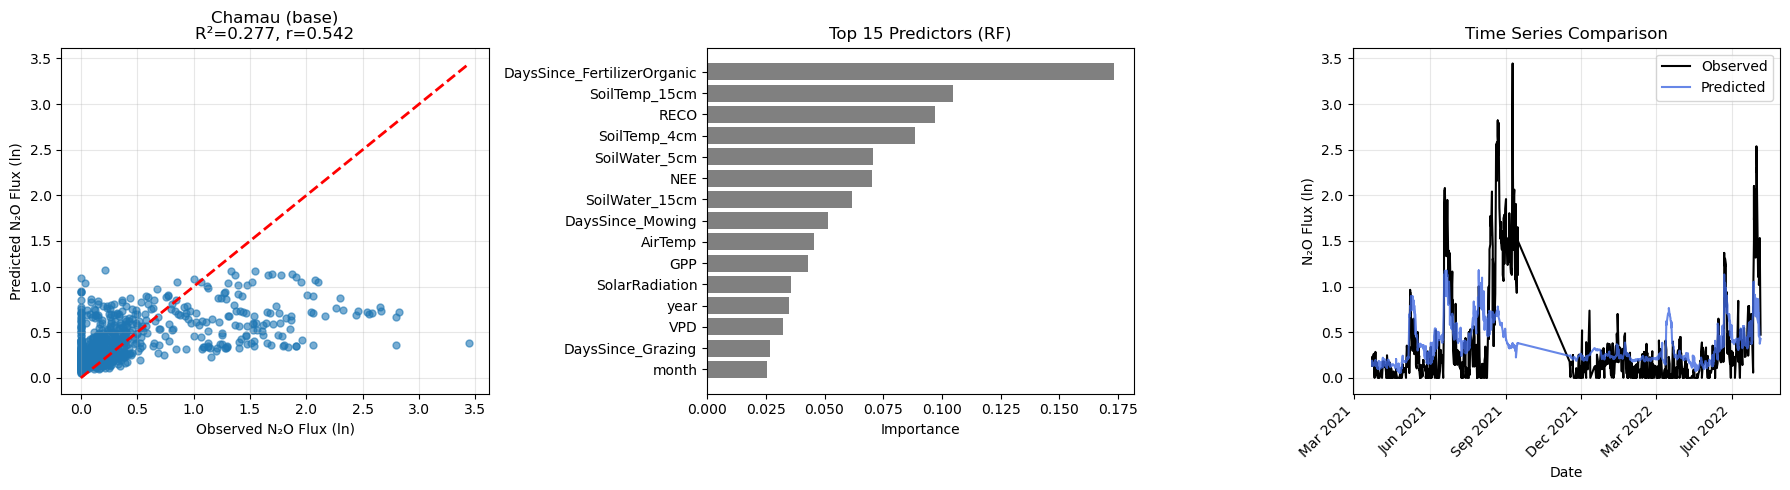


--- Chamau | predictors=augmented_lag ---
Chamau missing 77 predictors: ['AirTemp_lag1d', 'AirTemp_lag3d', 'AirTemp_lag5d', 'AirTemp_lag7d', 'DaysSince_Sowing']...
Chamau (augmented_lag): dropped 291 rows (6.7% of total) due to NaNs


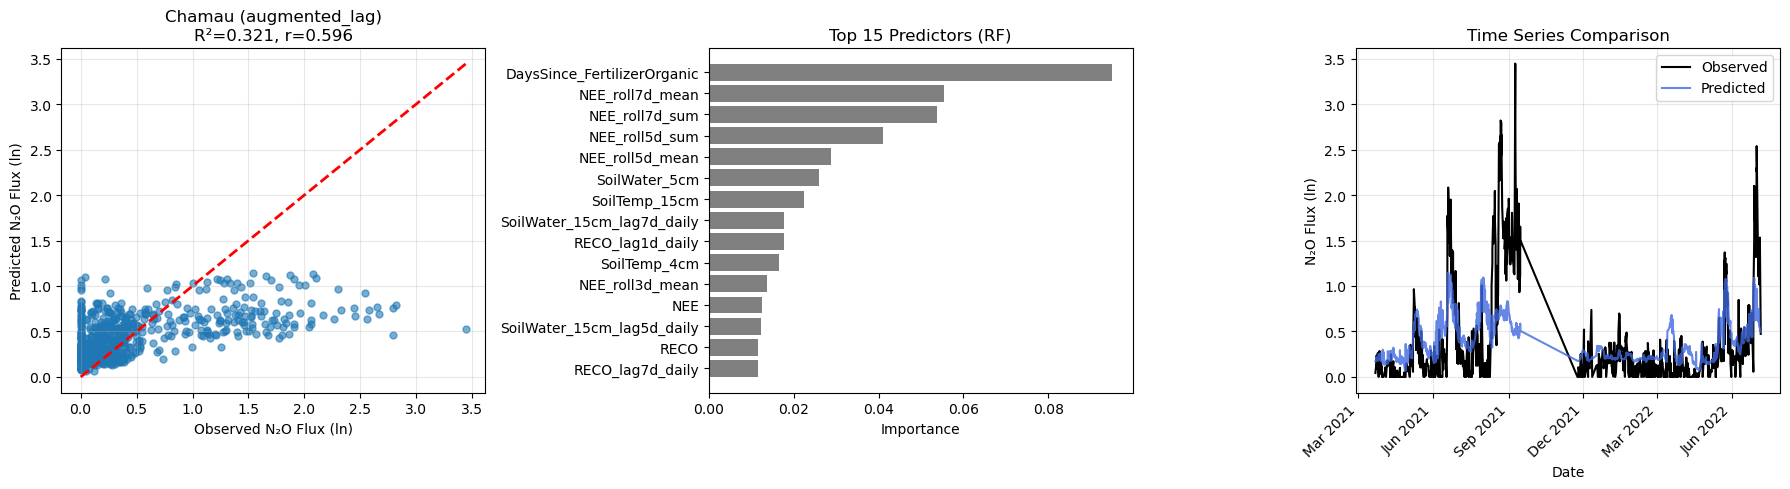


--- Chamau A | predictors=base ---
Chamau A missing 4 predictors: ['DaysSince_Sowing', 'SoilTemp_30cm', 'SoilTemp_5cm', 'SoilWater_30cm']
Chamau A (base): dropped 70 rows (5.5% of total) due to NaNs


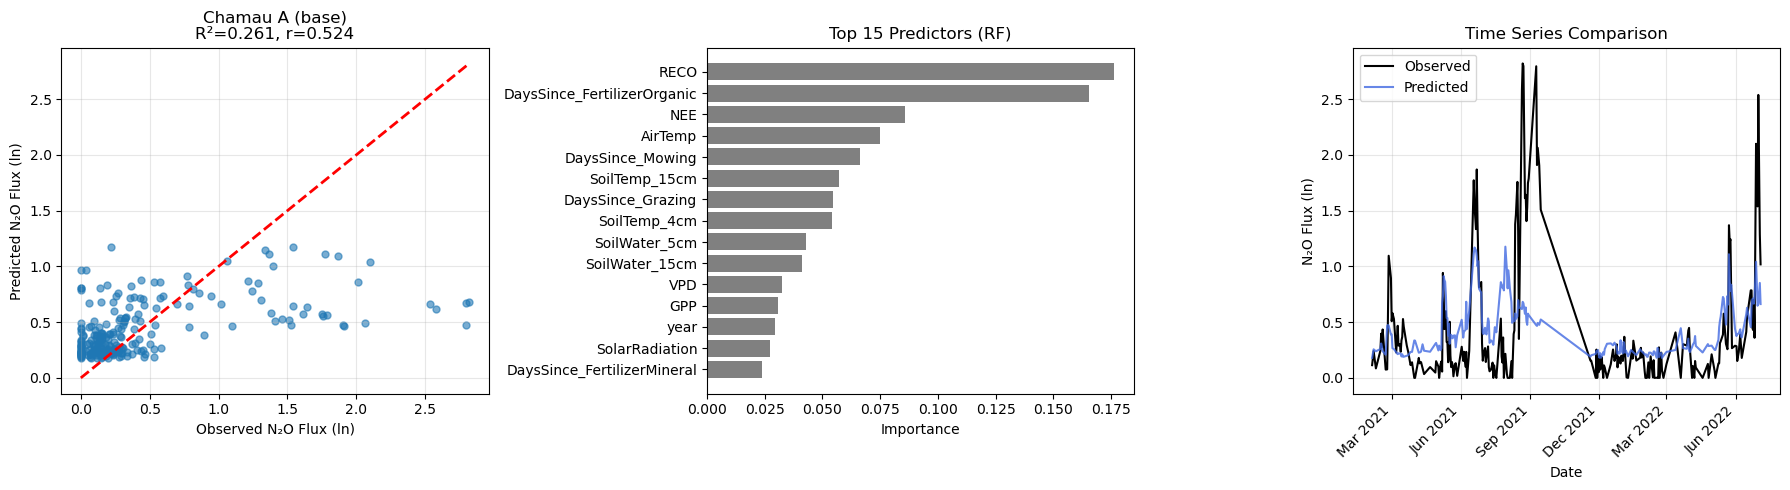


--- Chamau A | predictors=augmented_lag ---
Chamau A missing 77 predictors: ['AirTemp_lag1d', 'AirTemp_lag3d', 'AirTemp_lag5d', 'AirTemp_lag7d', 'DaysSince_Sowing']...
Chamau A (augmented_lag): dropped 83 rows (6.5% of total) due to NaNs


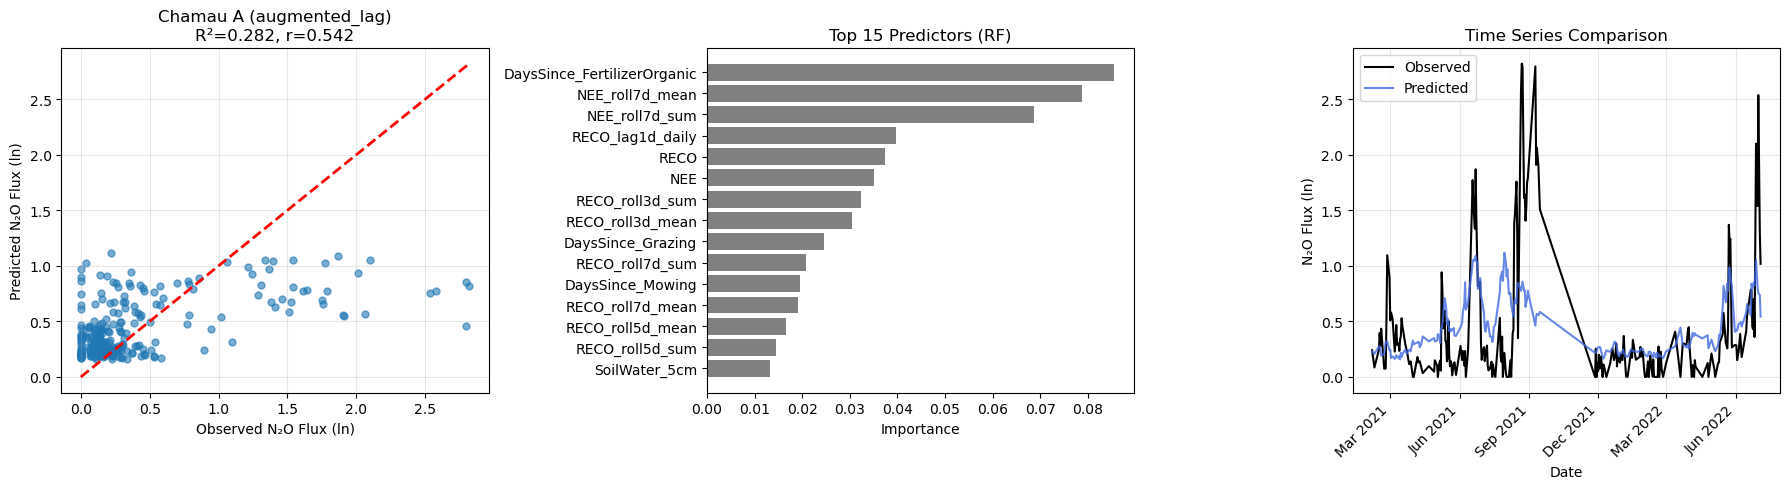


--- Chamau B | predictors=base ---
Chamau B missing 4 predictors: ['DaysSince_Sowing', 'SoilTemp_30cm', 'SoilTemp_5cm', 'SoilWater_30cm']
Chamau B (base): dropped 93 rows (5.7% of total) due to NaNs


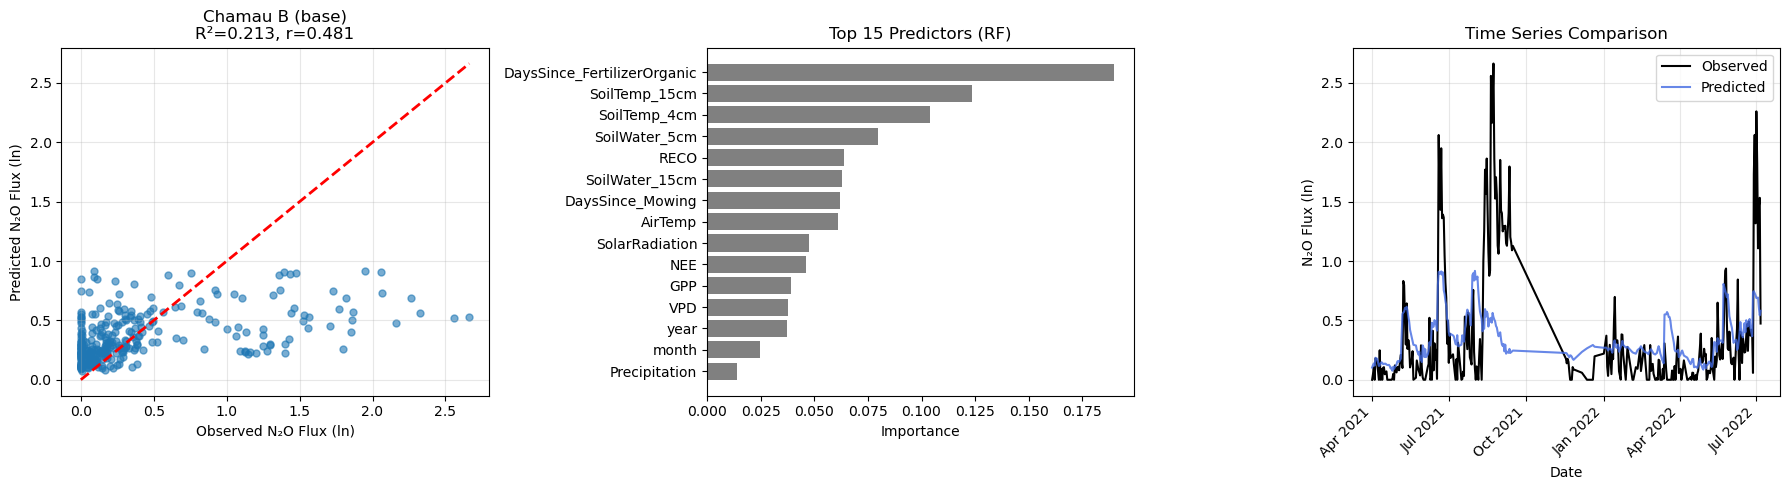


--- Chamau B | predictors=augmented_lag ---
Chamau B missing 77 predictors: ['AirTemp_lag1d', 'AirTemp_lag3d', 'AirTemp_lag5d', 'AirTemp_lag7d', 'DaysSince_Sowing']...
Chamau B (augmented_lag): dropped 117 rows (7.2% of total) due to NaNs


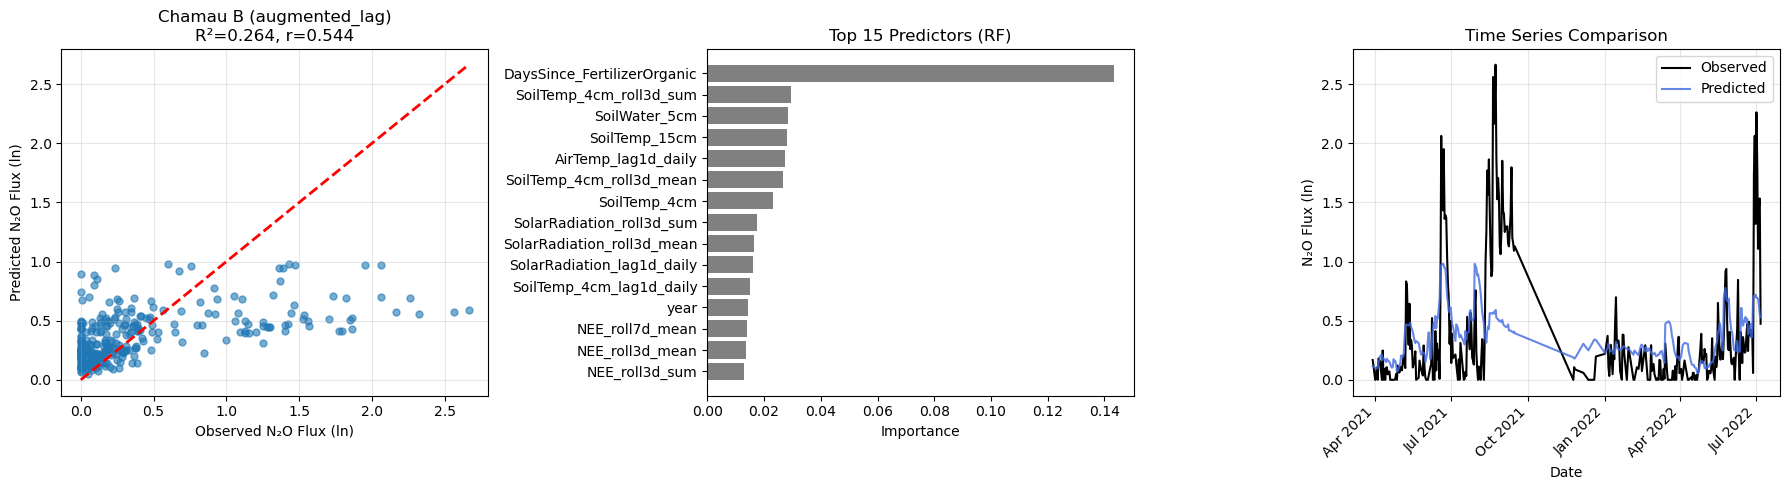


--- Aeschi | predictors=base ---
Aeschi missing 6 predictors: ['DaysSince_FertilizerMineral', 'DaysSince_FertilizerOrganic', 'DaysSince_Grazing', 'DaysSince_SoilCultivation', 'DaysSince_Sowing']...
Aeschi (base): dropped 0 rows (0.0% of total) due to NaNs


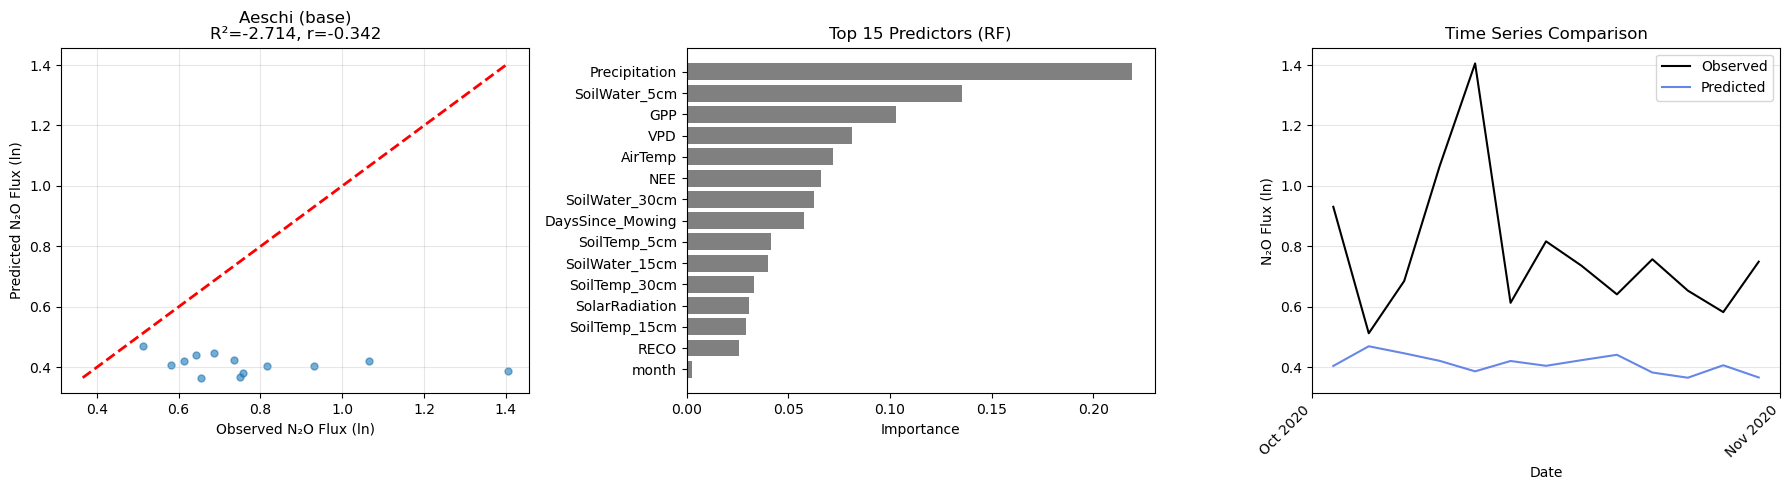


--- Aeschi | predictors=augmented_lag ---
Aeschi missing 59 predictors: ['AirTemp_lag1d_daily', 'AirTemp_lag3d_daily', 'AirTemp_lag5d_daily', 'AirTemp_lag7d_daily', 'DaysSince_FertilizerMineral']...
Aeschi (augmented_lag): dropped 7 rows (10.4% of total) due to NaNs


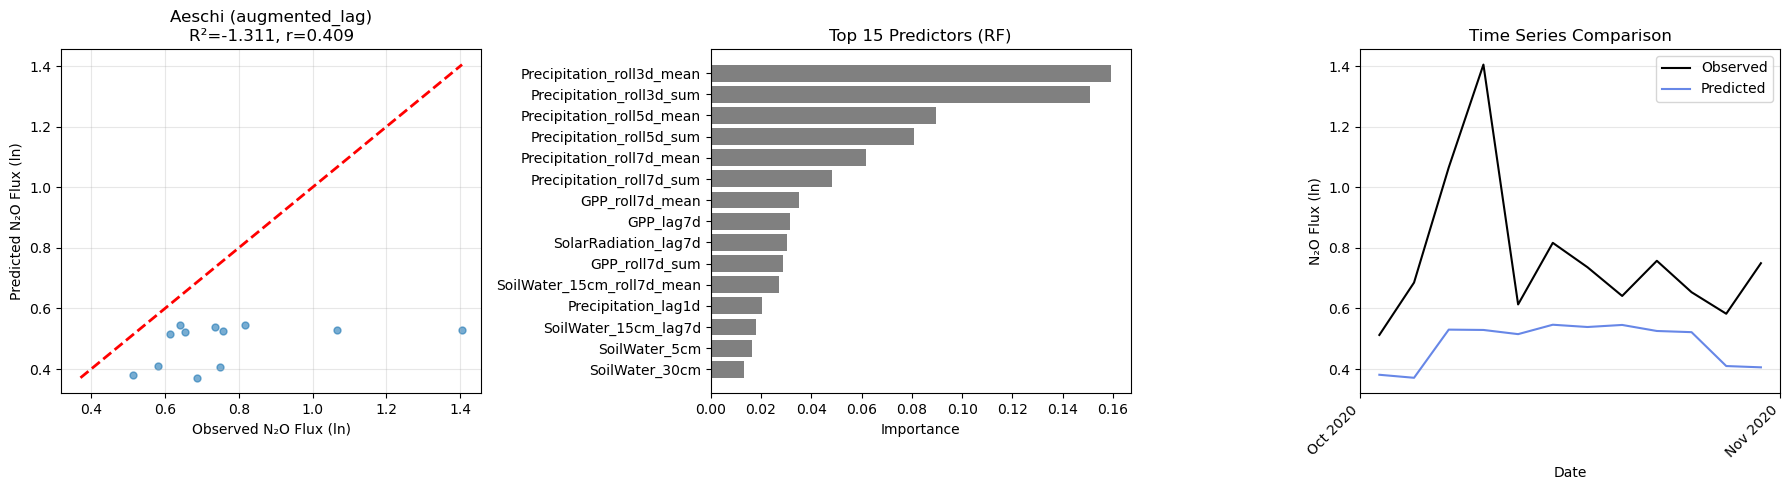


--- Oensingen 1 | predictors=base ---
Oensingen 1 missing 3 predictors: ['DaysSince_Grazing', 'DaysSince_Sowing', 'SoilTemp_4cm']
Oensingen 1 (base): dropped 5 rows (3.0% of total) due to NaNs


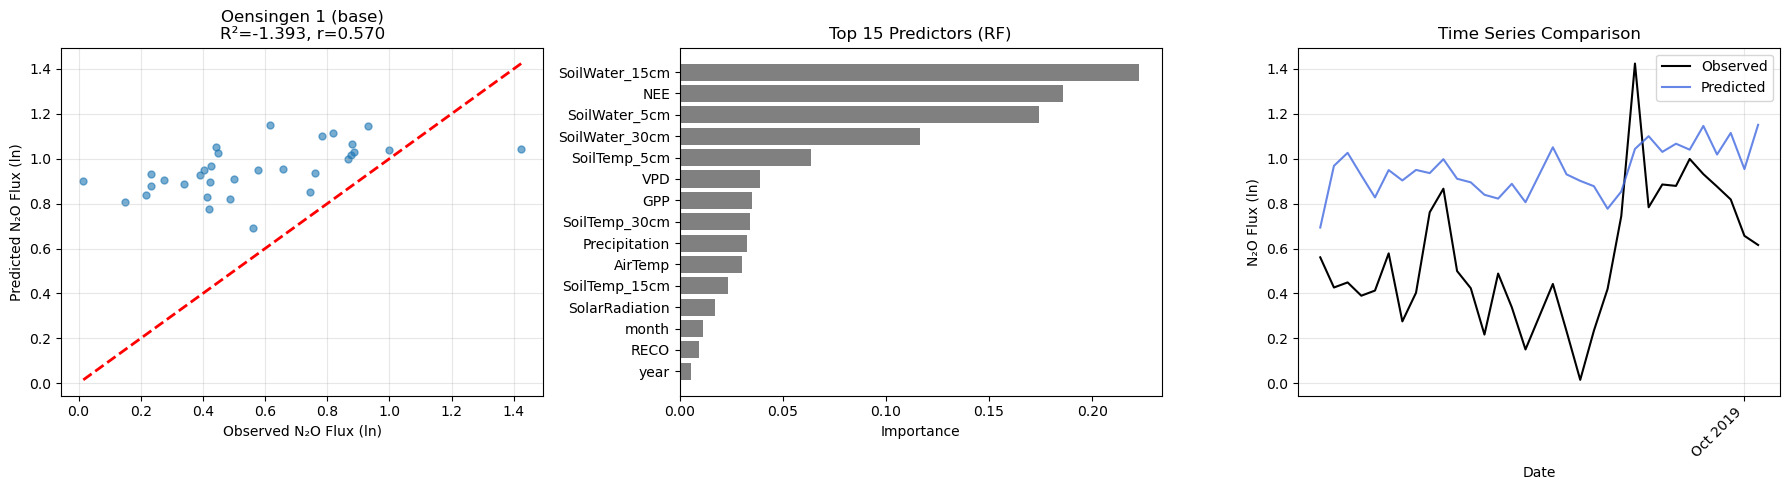


--- Oensingen 1 | predictors=augmented_lag ---
Oensingen 1 missing 56 predictors: ['AirTemp_lag1d_daily', 'AirTemp_lag3d_daily', 'AirTemp_lag5d_daily', 'AirTemp_lag7d_daily', 'DaysSince_Grazing']...
Oensingen 1 (augmented_lag): dropped 19 rows (11.5% of total) due to NaNs


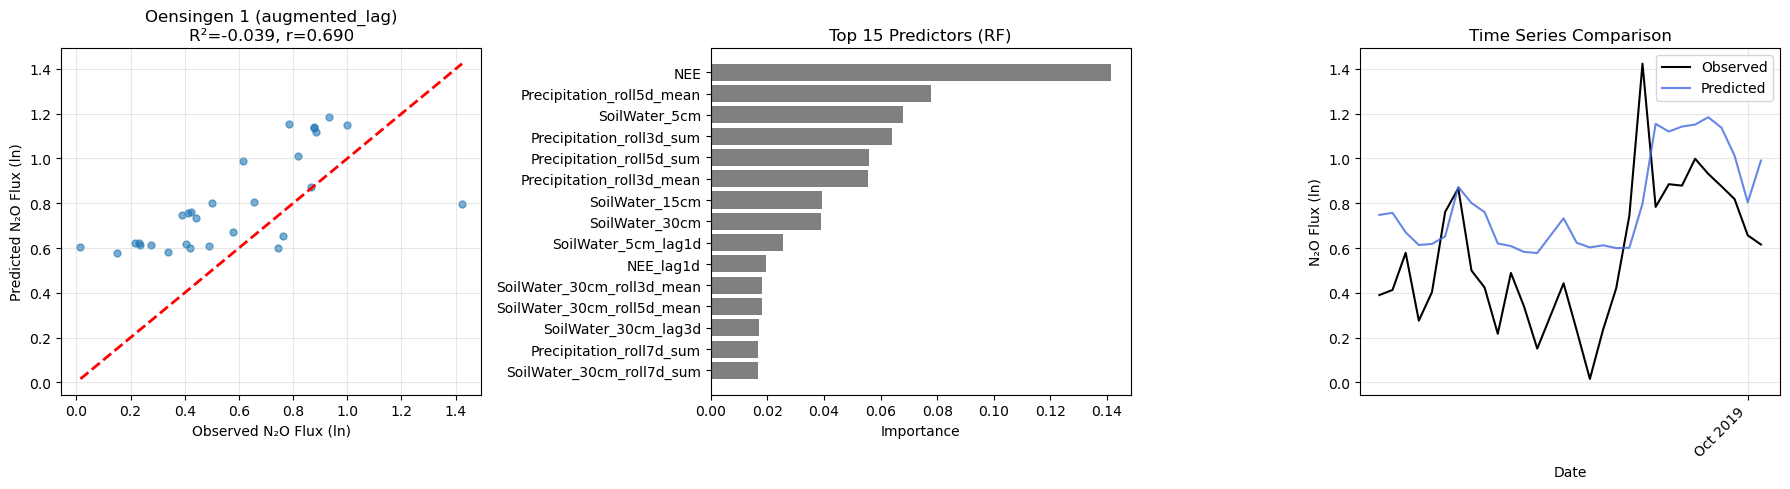


--- Oensingen 2 | predictors=base ---
Oensingen 2 missing 3 predictors: ['DaysSince_Grazing', 'DaysSince_Sowing', 'SoilTemp_4cm']
Oensingen 2 (base): dropped 0 rows (0.0% of total) due to NaNs


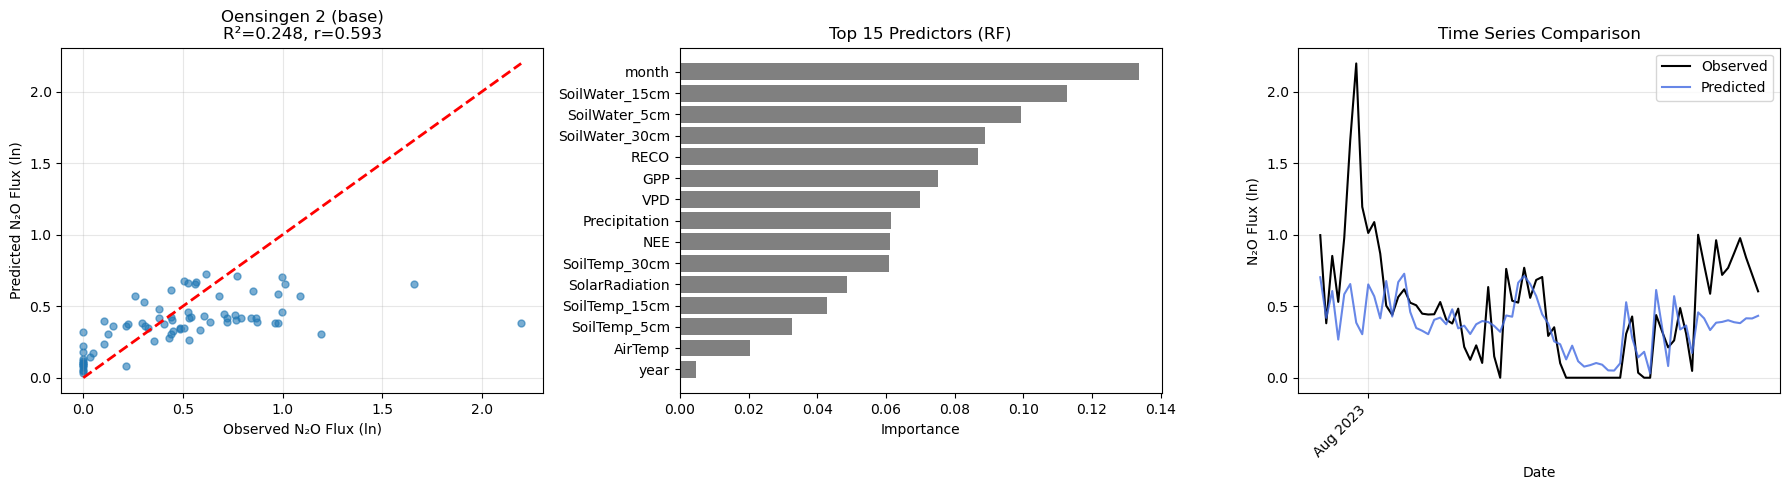


--- Oensingen 2 | predictors=augmented_lag ---
Oensingen 2 missing 56 predictors: ['AirTemp_lag1d_daily', 'AirTemp_lag3d_daily', 'AirTemp_lag5d_daily', 'AirTemp_lag7d_daily', 'DaysSince_Grazing']...
Oensingen 2 (augmented_lag): dropped 7 rows (1.9% of total) due to NaNs


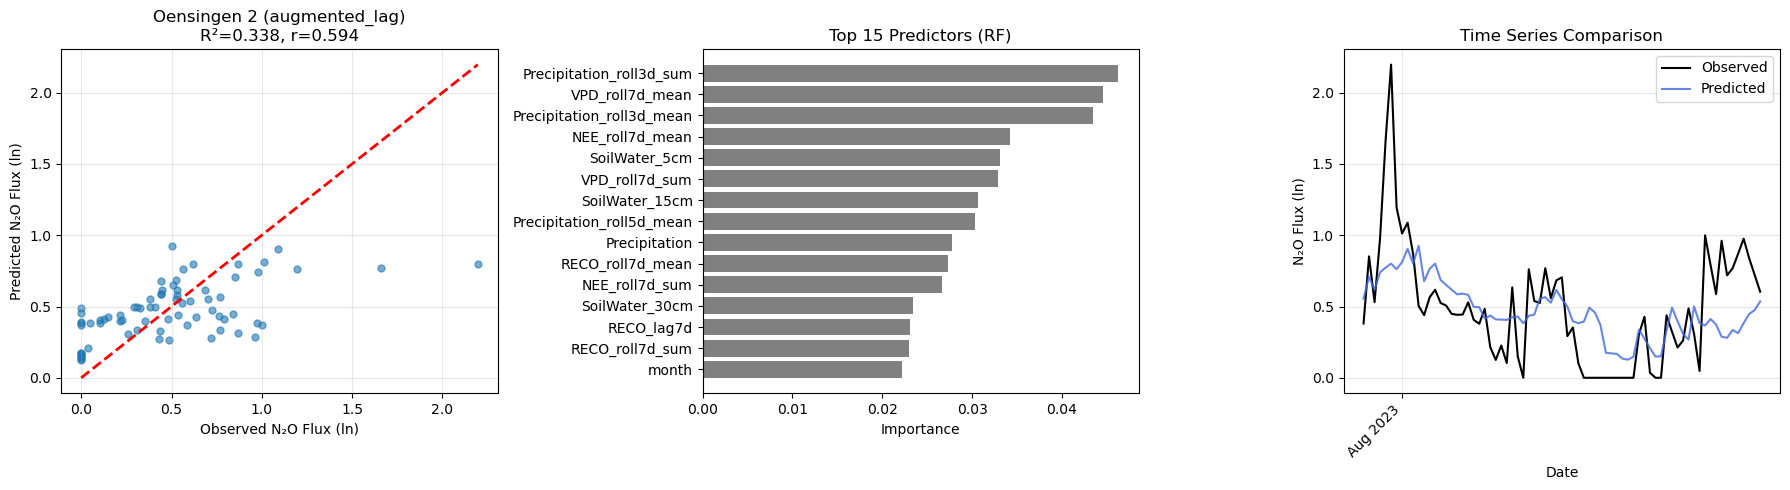


--- Tanikon | predictors=base ---
Tanikon missing 2 predictors: ['DaysSince_Grazing', 'SoilTemp_4cm']
Tanikon (base): dropped 112 rows (9.0% of total) due to NaNs


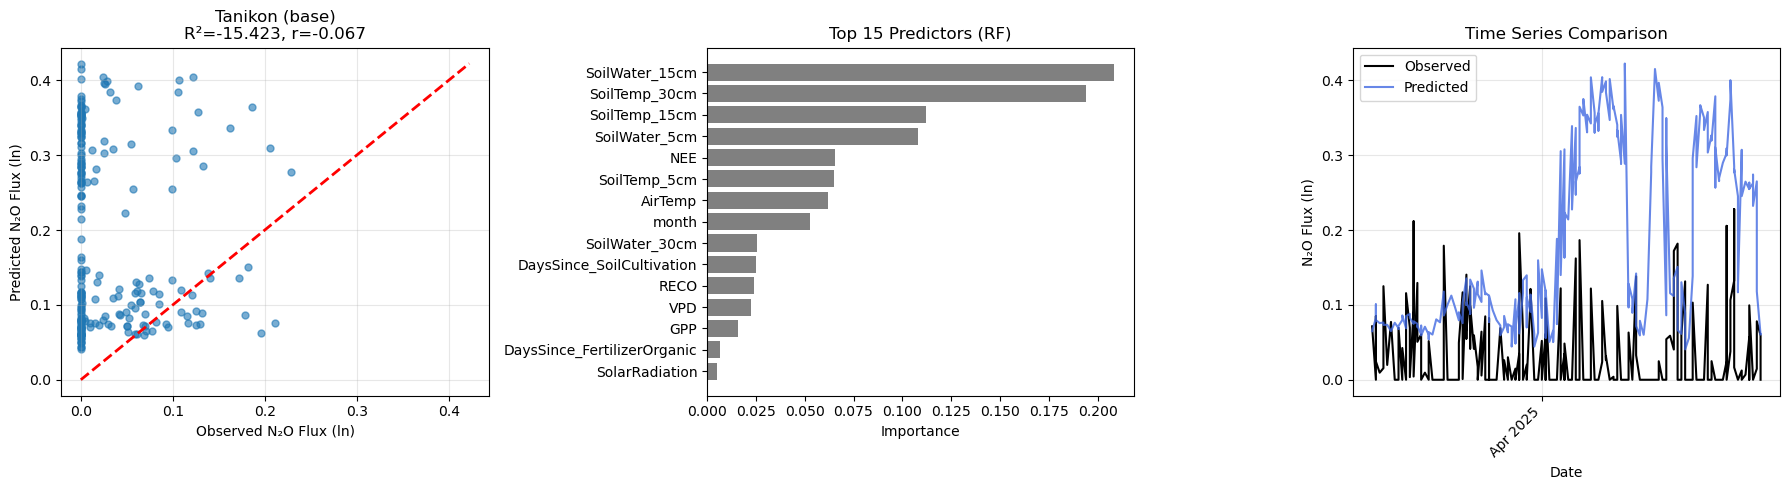


--- Tanikon | predictors=augmented_lag ---
Tanikon missing 55 predictors: ['AirTemp_lag1d_daily', 'AirTemp_lag3d_daily', 'AirTemp_lag5d_daily', 'AirTemp_lag7d_daily', 'DaysSince_Grazing']...
Tanikon (augmented_lag): dropped 152 rows (12.2% of total) due to NaNs


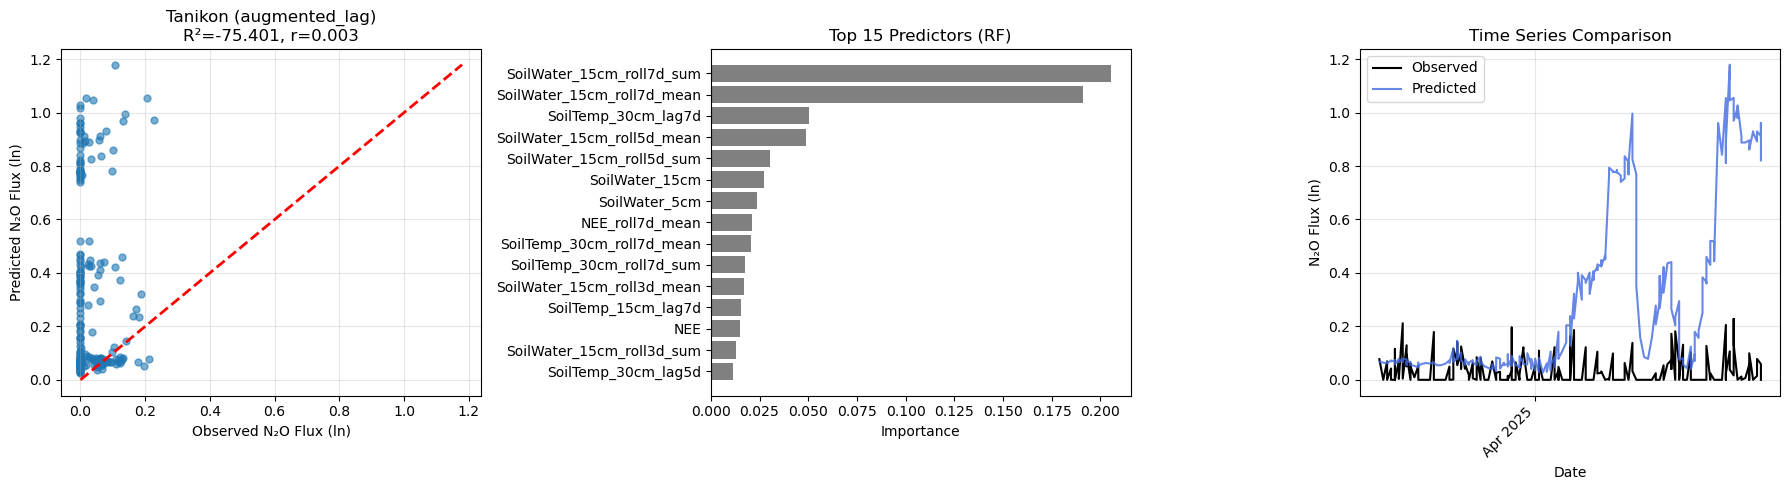


--- Tanikon A | predictors=base ---
Tanikon A missing 2 predictors: ['DaysSince_Grazing', 'SoilTemp_4cm']
Tanikon A (base): dropped 30 rows (7.2% of total) due to NaNs


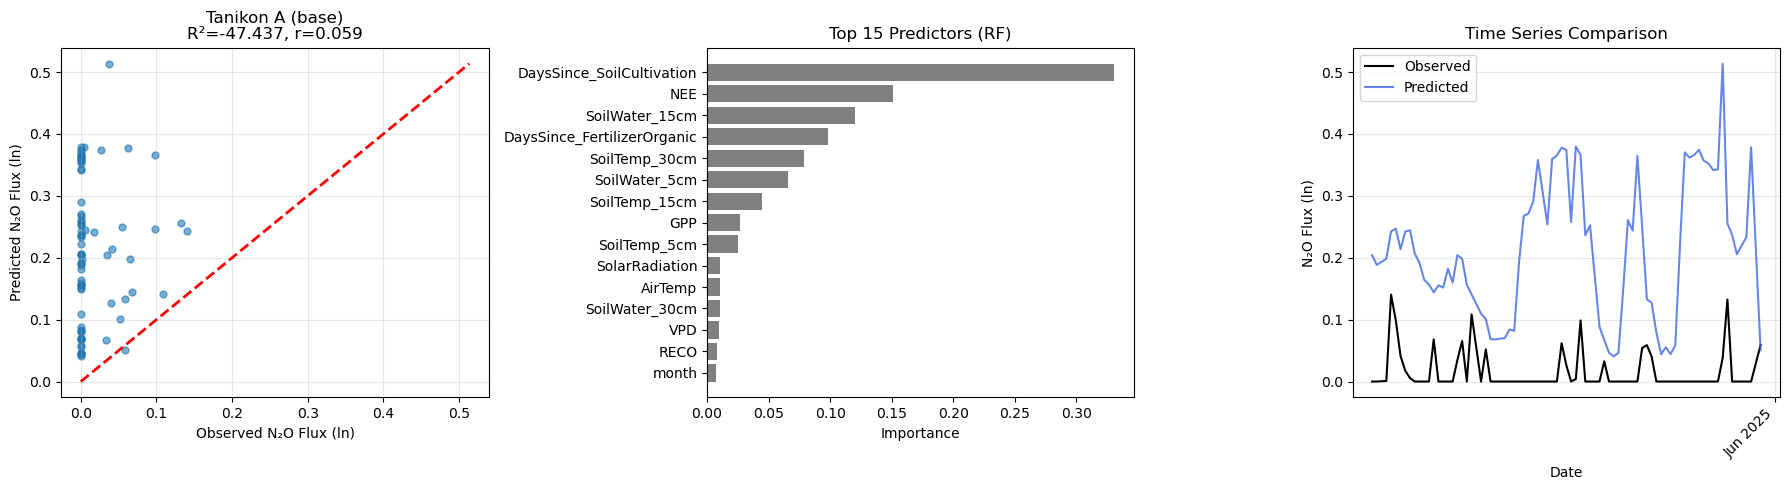


--- Tanikon A | predictors=augmented_lag ---
Tanikon A missing 55 predictors: ['AirTemp_lag1d_daily', 'AirTemp_lag3d_daily', 'AirTemp_lag5d_daily', 'AirTemp_lag7d_daily', 'DaysSince_Grazing']...
Tanikon A (augmented_lag): dropped 40 rows (9.6% of total) due to NaNs


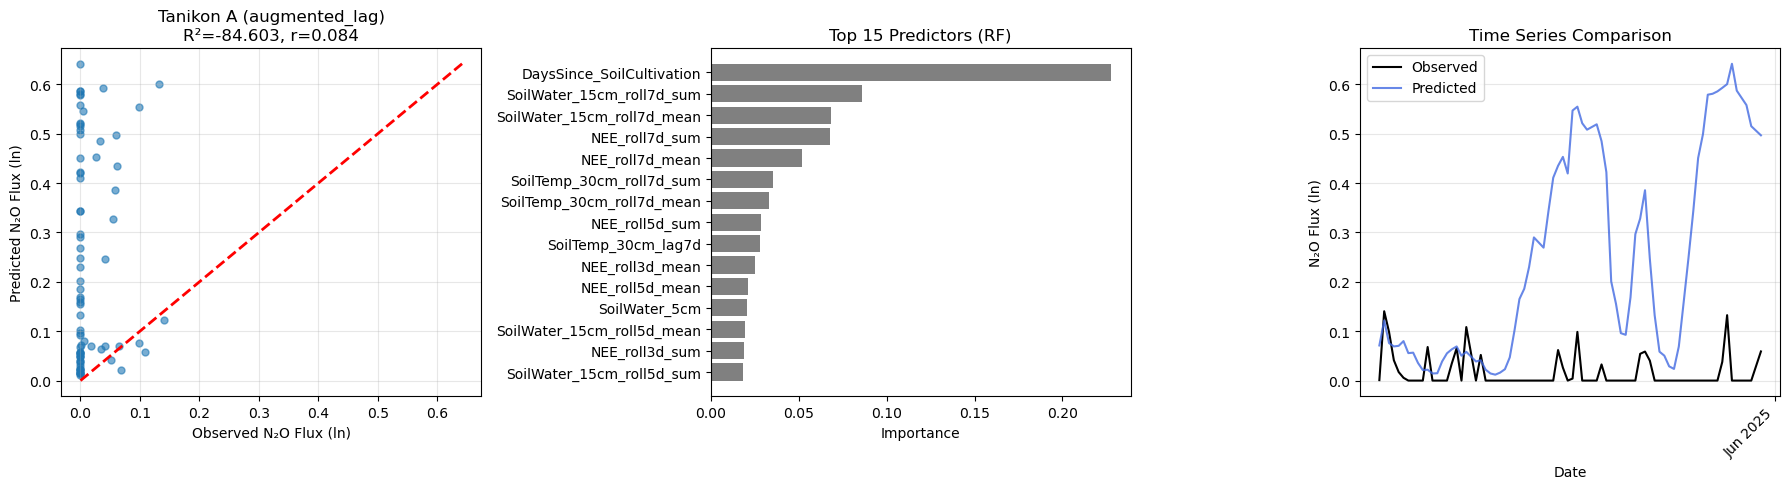


--- Tanikon B | predictors=base ---
Tanikon B missing 2 predictors: ['DaysSince_Grazing', 'SoilTemp_4cm']
Tanikon B (base): dropped 50 rows (10.9% of total) due to NaNs


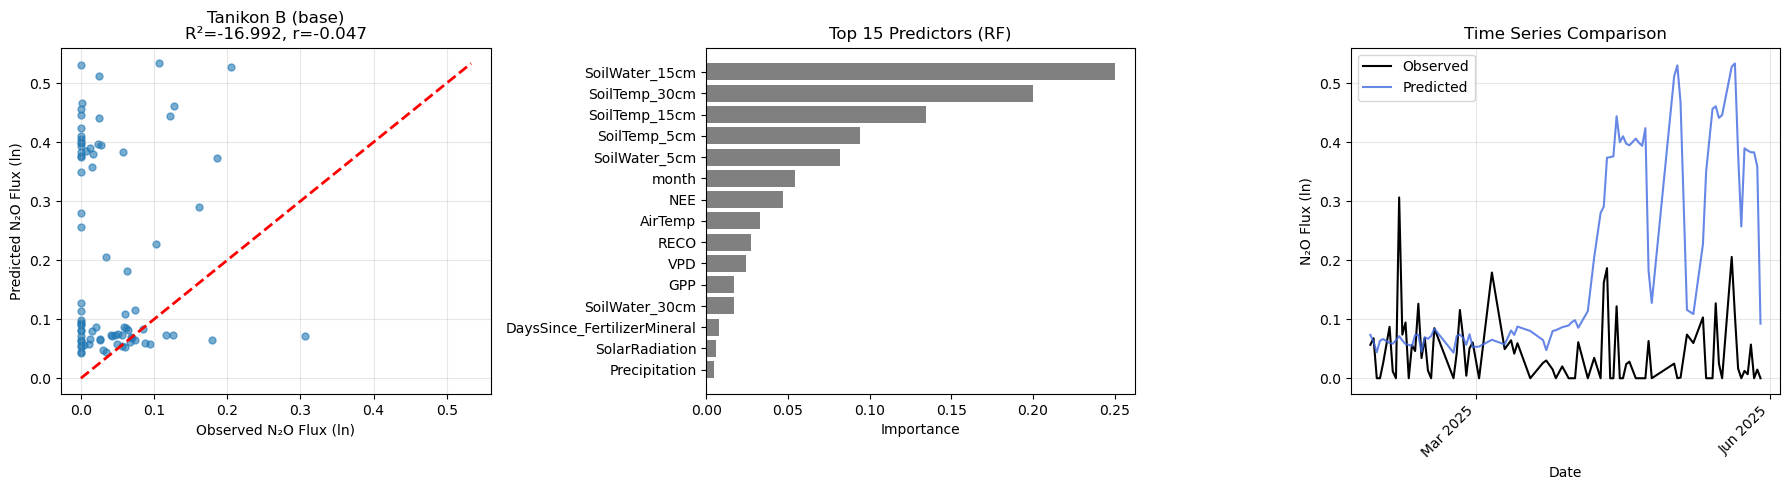


--- Tanikon B | predictors=augmented_lag ---
Tanikon B missing 55 predictors: ['AirTemp_lag1d_daily', 'AirTemp_lag3d_daily', 'AirTemp_lag5d_daily', 'AirTemp_lag7d_daily', 'DaysSince_Grazing']...
Tanikon B (augmented_lag): dropped 69 rows (15.0% of total) due to NaNs


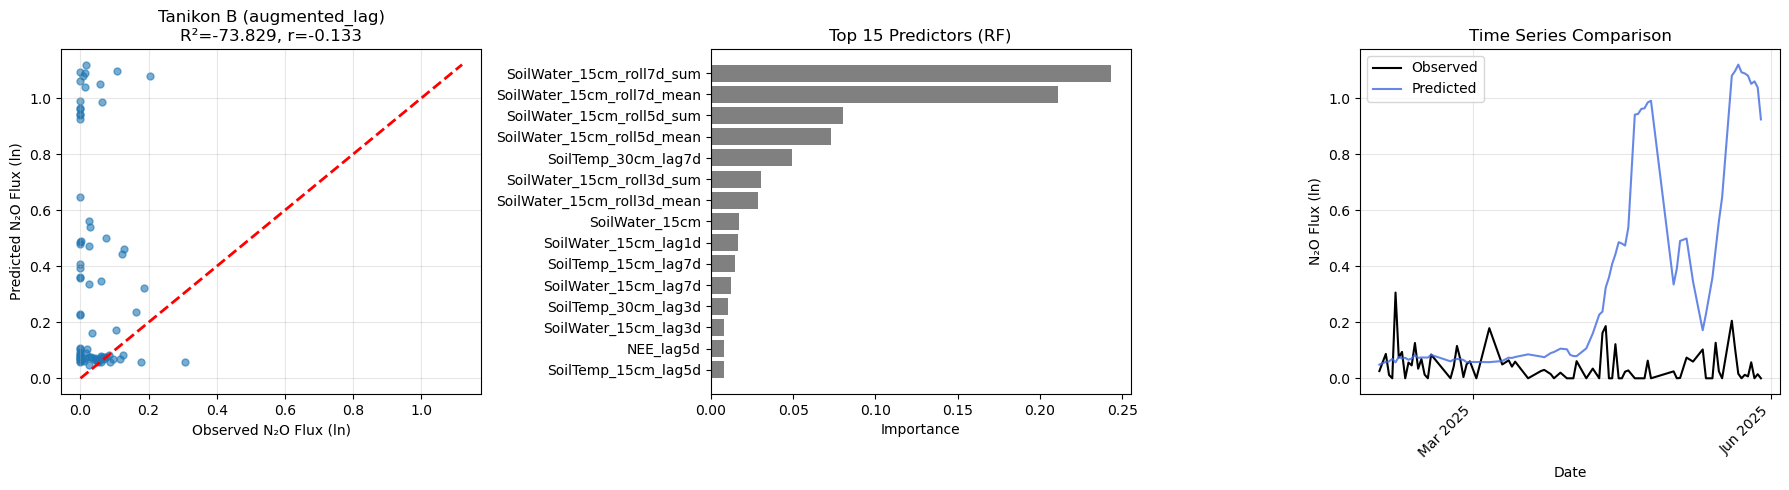


--- Forel | predictors=base ---
Forel missing 4 predictors: ['DaysSince_Grazing', 'DaysSince_SoilCultivation', 'DaysSince_Sowing', 'SoilTemp_4cm']
Forel (base): dropped 7 rows (1.7% of total) due to NaNs


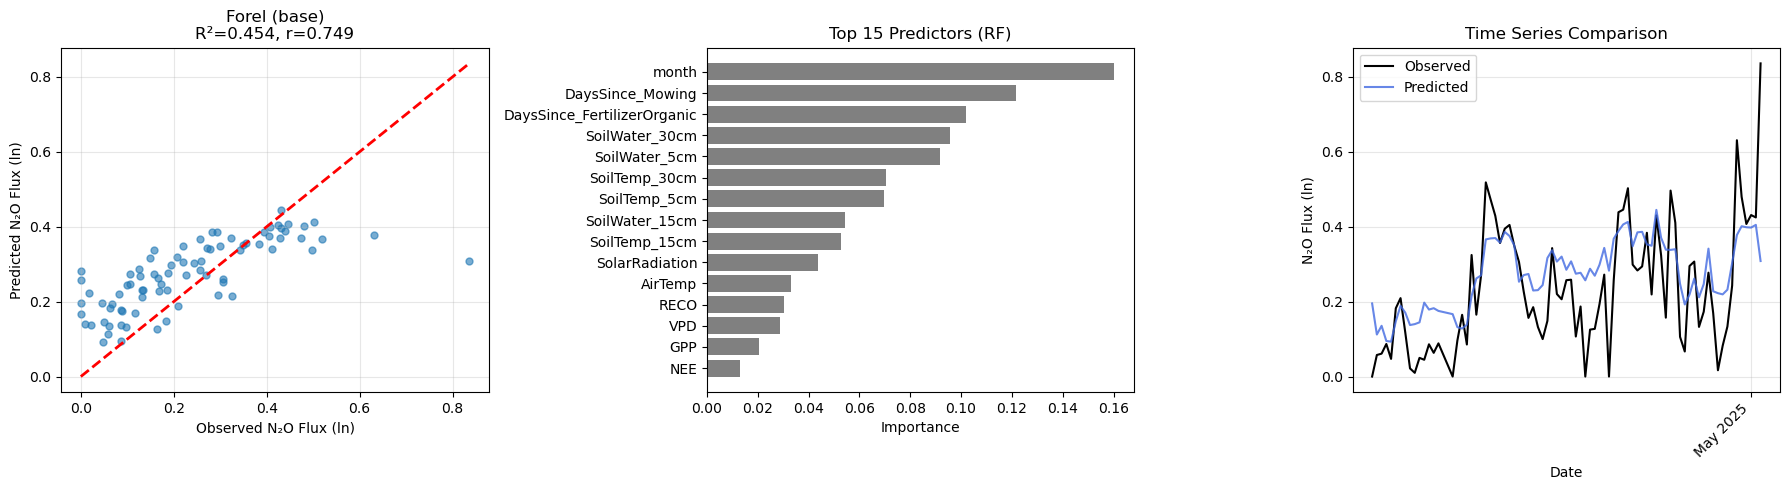


--- Forel | predictors=augmented_lag ---
Forel missing 57 predictors: ['AirTemp_lag1d_daily', 'AirTemp_lag3d_daily', 'AirTemp_lag5d_daily', 'AirTemp_lag7d_daily', 'DaysSince_Grazing']...
Forel (augmented_lag): dropped 14 rows (3.4% of total) due to NaNs


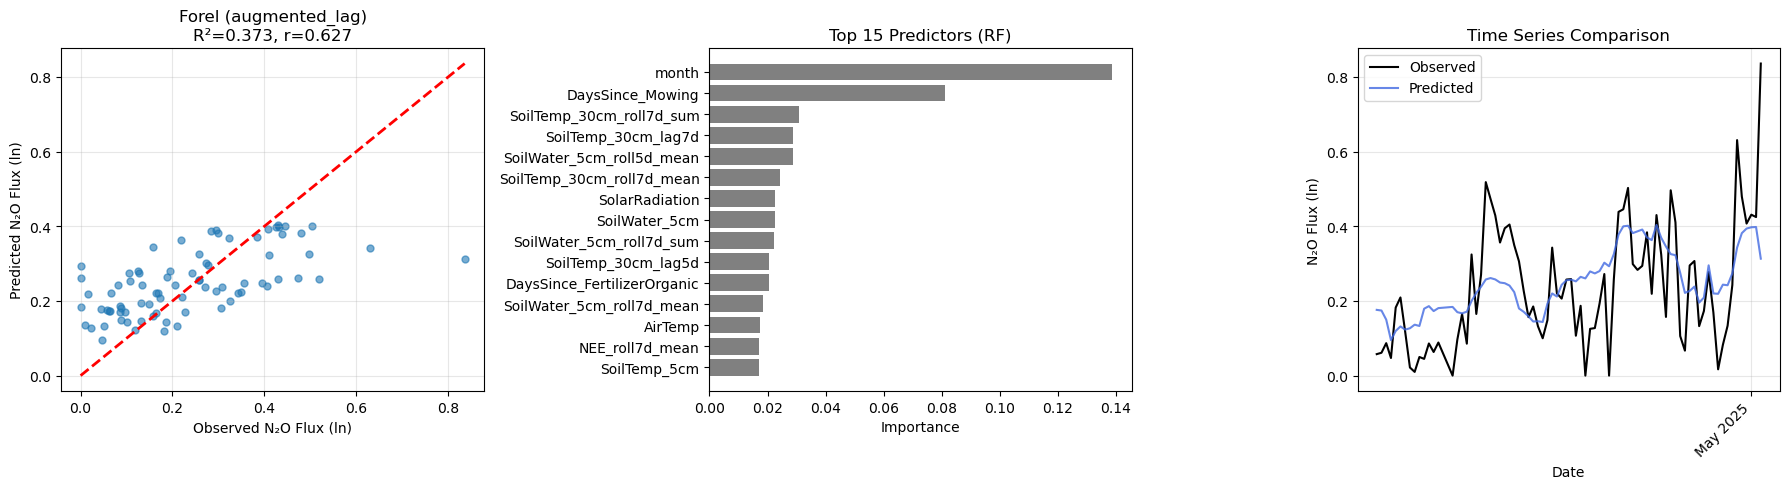

,Dataset,Predictor_Set,R²,Pearson_r,n_train,n_test
18,Forel,base,0.454,0.749,326,81
19,Forel,augmented_lag,0.373,0.627,320,80
11,Oensingen 2,augmented_lag,0.338,0.594,294,73
1,Chamau,augmented_lag,0.321,0.596,3239,809
3,Chamau A,augmented_lag,0.282,0.542,954,238
0,Chamau,base,0.277,0.542,3281,820
5,Chamau B,augmented_lag,0.264,0.544,1213,303
2,Chamau A,base,0.261,0.524,964,241
10,Oensingen 2,base,0.248,0.593,300,74
4,Chamau B,base,0.213,0.481,1232,308


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

results = []

for name, df in daily_datasets.items():
    for set_name, predictors in predictor_sets.items():
        print(f"\n--- {name} | predictors={set_name} ---")

        try:
            # --- Filter available predictors (same logic as ElasticNet) ---
            available_predictors = [p for p in predictors if p in df.columns]

            missing = set(predictors) - set(available_predictors)
            if missing:
                print(f"{name} missing {len(missing)} predictors: "
                      f"{sorted(list(missing))[:5]}{'...' if len(missing) > 5 else ''}")

            if len(available_predictors) < 5:
                print(f"Skipping {name} ({set_name}) — too few predictors left after filtering.")
                continue

            # --- Track NaN drops before training ---
            before_drop = len(df)
            df_clean = df.dropna(subset=available_predictors + [target])
            after_drop = len(df_clean)
            dropped = before_drop - after_drop
            pct_dropped = 100 * dropped / before_drop if before_drop > 0 else 0
            print(f"{name} ({set_name}): dropped {dropped} rows "
                  f"({pct_dropped:.1f}% of total) due to NaNs")

            if after_drop < 50:
                print(f"Skipping {name} ({set_name}) — not enough data after drop.")
                continue

            # --- Train Random Forest model ---
            res = train_rf_timeseries_simple(
                df_clean, available_predictors, target,
                date_col="Date", pca=False
            )

            # --- Append metrics ---
            results.append({
                "Dataset": name,
                "Predictor_Set": set_name,
                "R²": round(res["r2"], 3),
                "Pearson_r": round(res["pearson_r"], 3) if np.isfinite(res["pearson_r"]) else None,
                "n_train": res["n_train"],
                #"n_val": res["n_val"],
                "n_test": res["n_test"]
            })

            # --- Visualization section ---
            y_test = res["y_test"]
            y_pred = res["y_pred"]
            test_dates = pd.to_datetime(res["test_dates"])  # ensure datetime format
            
            # Convert to Series for alignment and plotting
            y_test_s = pd.Series(y_test, index=test_dates)
            y_pred_s = pd.Series(y_pred, index=test_dates)
            
            # Skip degenerate cases
            if np.std(y_pred) < 1e-6 or np.std(y_test) < 1e-6:
                print(f"{name} ({set_name}) → near-constant predictions or targets, skipping plot.")
                continue
            
            # --- Extract feature importance (RF only, skip PCA) ---
            model = res["model"]
            rf = model.named_steps["rf"] if "rf" in model.named_steps else model
            importances = pd.Series(rf.feature_importances_, index=available_predictors).sort_values(ascending=False)
            
            # ============================
            #   Combined 3-Panel Figure
            # ============================
            fig, axes = plt.subplots(1, 3, figsize=(18, 5))
            
            # 1) Scatter Plot
            axes[0].scatter(y_test, y_pred, alpha=0.6, s=25)
            min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
            axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
            axes[0].set_xlabel("Observed N₂O Flux (ln)")
            axes[0].set_ylabel("Predicted N₂O Flux (ln)")
            axes[0].set_title(f"{name} ({set_name})\nR²={res['r2']:.3f}, r={res['pearson_r']:.3f}")
            axes[0].grid(alpha=0.3)
            
            # 2) Top Feature Importance
            top = importances.head(15)
            axes[1].barh(top.index, top.values, color="gray")
            axes[1].invert_yaxis()
            axes[1].set_xlabel("Importance")
            axes[1].set_title("Top 15 Predictors (RF)")
            
            # 3) Time Series Comparison
            axes[2].plot(y_test_s.index, y_test_s.values, label="Observed", color="black", lw=1.5)
            axes[2].plot(y_pred_s.index, y_pred_s.values, label="Predicted", color="royalblue", lw=1.5, alpha=0.8)
            axes[2].set_xlabel("Date")
            axes[2].set_ylabel("N₂O Flux (ln)")
            axes[2].set_title("Time Series Comparison")
            axes[2].legend()
            axes[2].grid(alpha=0.3)
            
            # Time formatting
            axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
            plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
            
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Skipped {name} ({set_name}) due to error: {e}")
            results.append({
                "Dataset": name,
                "Predictor_Set": set_name,
                "R²": None,
                "Pearson_r": None,
                "n_train": None,
                #"n_val": None,
                "n_test": None
            })

# --- Final summary ---
results_df = pd.DataFrame(results).sort_values(by=["R²", "Pearson_r"], ascending=False)
display(results_df)
